# Ranking and probability quality

<a target="_blank" href="https://colab.research.google.com/github/changyaochen/MECE4520/blob/master/site/classification/04-ranking-and-calibration.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>

The previous notebook evaluated an alert decision after choosing a probability
threshold. A classifier also produces probability scores that we can evaluate
without fixing one threshold. Here, we separate three questions:

1. Can the model **rank** high-CO observations above not-high-CO observations?
2. Are its numerical probability values **useful**?
3. Do probabilities match the observed frequencies—that is, are they
   **calibrated**?


## 1. Fit the TIT-based probability model

As before, each row is one gas-turbine operating observation. The target
`high_co` equals 1 when measured CO is at least 2 mg/m³. We train logistic
regression with turbine inlet temperature (TIT) as its one feature, then keep a
test set for comparison.


In [1]:
from pathlib import Path
from urllib.request import urlretrieve

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    log_loss,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid", context="notebook")

DATA_URL = "https://raw.githubusercontent.com/changyaochen/MECE4520/master/site/data/gas-turbine-course.csv"
candidates = [
    Path("../data/gas-turbine-course.csv"),
    Path("site/data/gas-turbine-course.csv"),
    Path("gas-turbine-course.csv"),
]
data_path = next((path for path in candidates if path.exists()), candidates[-1])

# In Google Colab, download the small course dataset if it is not already present.
if not data_path.exists():
    urlretrieve(DATA_URL, data_path)

data = pd.read_csv(data_path)
model_data = data[["TIT", "high_co"]].dropna().copy()
X = model_data[["TIT"]]
y = model_data["high_co"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=4520, stratify=y
)

model = LogisticRegression(max_iter=1_000).fit(X_train, y_train)
train_probabilities = model.predict_proba(X_train)[:, 1]
test_probabilities = model.predict_proba(X_test)[:, 1]


## 2. Trace precision, recall, and F1 across thresholds

The previous notebook calculated precision, recall, and F1 after choosing one
alert threshold. Here, we sweep the same threshold $\tau$ from strict to
permissive and watch those quantities change.

$$
\operatorname{Precision}(\tau) =
\frac{TP(\tau)}{TP(\tau)+FP(\tau)},
\qquad
\operatorname{Recall}(\tau) =
\frac{TP(\tau)}{TP(\tau)+FN(\tau)}.
$$

Precision asks: *among the observations labeled high CO, how many actually have
high CO?* Recall asks: *among all actual high-CO observations, how many did we
find?* Lowering $\tau$ usually increases recall, but it can decrease
precision as more false alerts are included.

The F1 score summarizes their balance:

$$
F_1(\tau) =
\frac{2\,\operatorname{Precision}(\tau)\,
\operatorname{Recall}(\tau)}
{\operatorname{Precision}(\tau)+\operatorname{Recall}(\tau)}.
$$

The two plots below use the training predictions so they match the interactive
explorer. The horizontal reference line is the fraction of high-CO observations
in the training data; it is the precision from labeling every observation
positive.


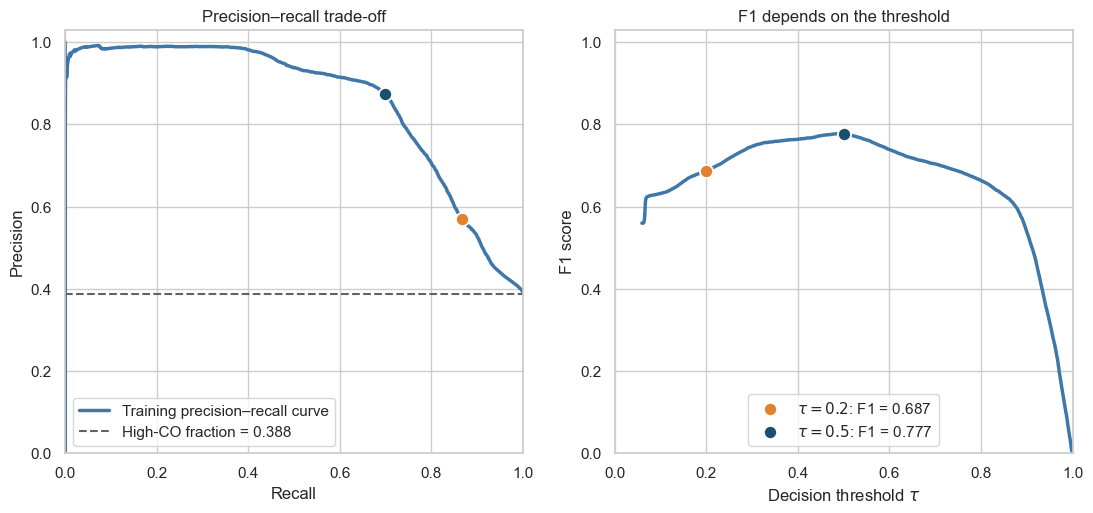

In [2]:
train_precision, train_recall, train_thresholds = precision_recall_curve(
    y_train, train_probabilities
)

# Precision and recall include one endpoint with no matching threshold.
train_f1 = np.divide(
    2 * train_precision[:-1] * train_recall[:-1],
    train_precision[:-1] + train_recall[:-1],
    out=np.zeros_like(train_thresholds),
    where=(train_precision[:-1] + train_recall[:-1]) != 0,
)

fig, (ax_pr, ax_f1) = plt.subplots(1, 2, figsize=(13, 5.5))

ax_pr.plot(
    train_recall,
    train_precision,
    color="#3F78A8",
    linewidth=2.5,
    label="Training precision–recall curve",
)
ax_pr.axhline(
    y_train.mean(),
    color="#5F6368",
    linestyle="--",
    label=f"High-CO fraction = {y_train.mean():.3f}",
)

for threshold, color in [(0.20, "#E1812C"), (0.50, "#1B4F72")]:
    predicted_labels = (train_probabilities >= threshold).astype(int)
    precision_value = (predicted_labels[y_train.to_numpy() == 1].sum()
                       / predicted_labels.sum())
    recall_value = predicted_labels[y_train.to_numpy() == 1].mean()
    f1_value = 2 * precision_value * recall_value / (precision_value + recall_value)

    ax_pr.scatter(
        recall_value,
        precision_value,
        color=color,
        edgecolor="white",
        linewidth=1.3,
        s=90,
        zorder=3,
    )
    ax_f1.scatter(
        threshold,
        f1_value,
        color=color,
        edgecolor="white",
        linewidth=1.3,
        s=90,
        zorder=3,
        label=rf"$\tau={threshold:.1f}$: F1 = {f1_value:.3f}",
    )

ax_pr.set(
    xlabel="Recall",
    ylabel="Precision",
    title="Precision–recall trade-off",
    xlim=(0, 1),
    ylim=(0, 1.03),
)
ax_pr.legend(loc="lower left", frameon=True)

ax_f1.plot(
    train_thresholds,
    train_f1,
    color="#3F78A8",
    linewidth=2.5,
)
ax_f1.set(
    xlabel=r"Decision threshold $\tau$",
    ylabel="F1 score",
    title="F1 depends on the threshold",
    xlim=(0, 1),
    ylim=(0, 1.03),
)
ax_f1.legend(loc="lower center", frameon=True)
plt.show()


## 3. Measure ranking with ROC and area under the curve (AUC)

At a threshold $\tau$, the **true-positive rate** and **false-positive rate**
are

$$
\operatorname{TPR}(\tau) = \frac{TP(\tau)}{TP(\tau)+FN(\tau)},
\qquad
\operatorname{FPR}(\tau) = \frac{FP(\tau)}{FP(\tau)+TN(\tau)}.
$$

An ROC curve traces TPR against FPR as $\tau$ moves from a strict threshold to
a permissive one. The **area under the ROC curve (AUC)** summarizes ranking
quality: it is the chance
that the model assigns a randomly chosen high-CO observation a higher score
than a randomly chosen not-high-CO observation. An AUC of 0.5 corresponds to
random ranking.


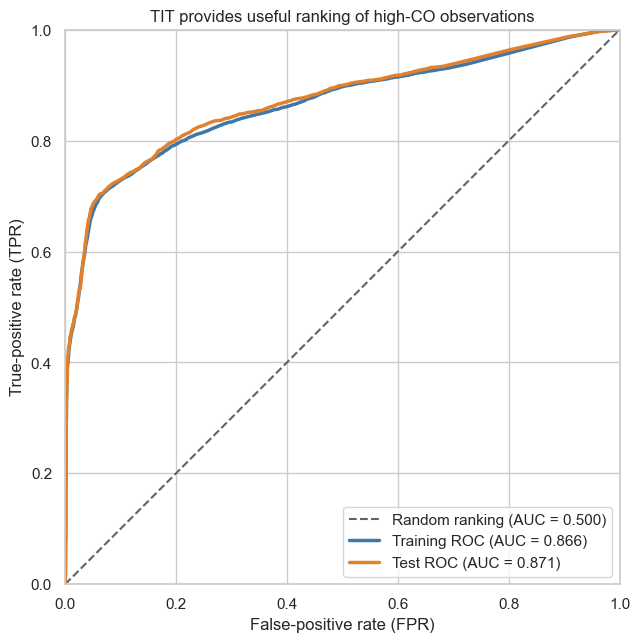

In [3]:
train_fpr, train_tpr, _ = roc_curve(y_train, train_probabilities)
test_fpr, test_tpr, _ = roc_curve(y_test, test_probabilities)
train_auc = roc_auc_score(y_train, train_probabilities)
test_auc = roc_auc_score(y_test, test_probabilities)

fig, ax = plt.subplots(figsize=(7.2, 7.2))
ax.plot([0, 1], [0, 1], "--", color="#5F6368",
        label="Random ranking (AUC = 0.500)")
ax.plot(train_fpr, train_tpr, color="#3F78A8", linewidth=2.5,
        label=f"Training ROC (AUC = {train_auc:.3f})")
ax.plot(test_fpr, test_tpr, color="#E1812C", linewidth=2.5,
        label=f"Test ROC (AUC = {test_auc:.3f})")
ax.set(
    xlabel="False-positive rate (FPR)",
    ylabel="True-positive rate (TPR)",
    title="TIT provides useful ranking of high-CO observations",
    xlim=(0, 1),
    ylim=(0, 1),
    aspect="equal",
)
ax.legend(loc="lower right", frameon=True)
plt.show()


[Explore how the ROC curve, precision–recall curve, and F1 score change together as the threshold moves](threshold-explorer.qmd).

## 4. Measure probability quality with log loss

AUC only cares about the ordering of scores. It does not check whether a
predicted probability such as 0.90 is numerically credible. For that, we use
the binary cross-entropy introduced with logistic regression, often called
**log loss**:

$$
\operatorname{LogLoss} = -\frac{1}{n}\sum_{i=1}^{n}
\left[y_i\log(\hat p_i) + (1-y_i)\log(1-\hat p_i)\right].
$$

To make this scale interpretable, compare it with the loss from predicting the
test-set high-CO fraction $\bar y$ for every observation:

$$
H(\bar y) = -\bar y\log(\bar y) - (1-\bar y)\log(1-\bar y),
\qquad
\text{normalized log loss} = \frac{\operatorname{LogLoss}}{H(\bar y)}.
$$

A normalized log loss of 1 means the model is no better than this
constant-probability baseline; lower values are better.


In [4]:
# Make deliberately overconfident predictions without changing their rank.
test_scores = model.decision_function(X_test)
sharpened_probabilities = 1 / (1 + np.exp(-5 * test_scores))

test_prevalence = y_test.mean()
baseline_log_loss = -(
    test_prevalence * np.log(test_prevalence)
    + (1 - test_prevalence) * np.log(1 - test_prevalence)
)

probability_quality = pd.DataFrame(
    {
        "AUC": [
            roc_auc_score(y_test, test_probabilities),
            roc_auc_score(y_test, sharpened_probabilities),
        ],
        "log loss": [
            log_loss(y_test, test_probabilities),
            log_loss(y_test, sharpened_probabilities),
        ],
    },
    index=["Original TIT model", "Overconfident $5z$ scores"],
)
probability_quality["normalized log loss"] = (
    probability_quality["log loss"] / baseline_log_loss
)
probability_quality.style.format(
    {"AUC": "{:.3f}", "log loss": "{:.3f}",
     "normalized log loss": "{:.3f}"}
)


,AUC,log loss,normalized log loss
Original TIT model,0.871,0.412,0.617
Overconfident $5z$ scores,0.871,1.011,1.514


Multiplying every log-odds score $z_i$ by 5 is strictly increasing, so it
preserves the ranking and therefore AUC. But it moves probabilities closer to 0
and 1. When the model is wrong, it is now much more confidently wrong, which
log loss penalizes heavily.

## 5. Check calibration with a reliability diagram

Calibration asks whether the probability values mean what they say. For
example, among test observations assigned probabilities near 0.70, we would
hope that approximately 70% actually have high CO. A reliability diagram bins
the predicted probabilities and compares their mean with the observed
high-CO fraction in each bin.


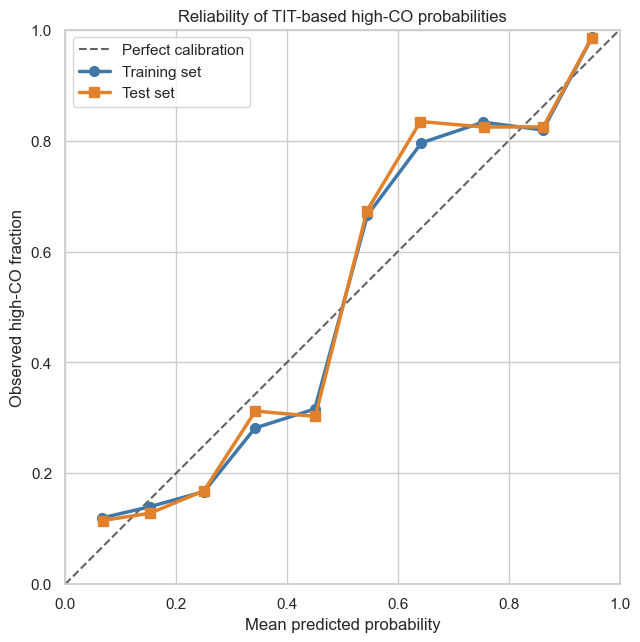

In [5]:
def reliability_points(labels, probabilities, n_bins=10):
    """Return observed fractions and mean predictions in probability bins."""
    observed_fraction, mean_prediction = calibration_curve(
        labels, probabilities, n_bins=n_bins, strategy="uniform"
    )
    return observed_fraction, mean_prediction


fig, ax = plt.subplots(figsize=(7.2, 7.2))
ax.plot([0, 1], [0, 1], "--", color="#5F6368",
        label="Perfect calibration")
for labels, probabilities, label, color, marker in [
    (y_train, train_probabilities, "Training set", "#3F78A8", "o"),
    (y_test, test_probabilities, "Test set", "#E1812C", "s"),
]:
    observed_fraction, mean_prediction = reliability_points(labels, probabilities)
    ax.plot(mean_prediction, observed_fraction, color=color, marker=marker,
            markersize=7, linewidth=2.5, label=label)

ax.set(
    xlabel="Mean predicted probability",
    ylabel="Observed high-CO fraction",
    title="Reliability of TIT-based high-CO probabilities",
    xlim=(0, 1),
    ylim=(0, 1),
    aspect="equal",
)
ax.legend(loc="upper left", frameon=True)
plt.show()


## 6. Choose the metric that answers the question

| Question | Useful evaluation |
|---|---|
| Which observations should be investigated first? | ROC and AUC: ranking quality |
| How good is a particular alert policy? | Confusion matrix, precision, recall, F1, and operating cost |
| Can a probability support a cost-based decision? | Log loss and calibration |

No one metric is universally sufficient. The choice follows the engineering
decision that the model is meant to support.

## Try it

Change the multiplier from 5 to 2 in the $5z$ example, rerun the cell, and
compare AUC with log loss again.

[← Return to Classification](index.qmd)


In [6]:
# Try a less extreme score multiplier.
# alternative_probabilities = 1 / (1 + np.exp(-2 * test_scores))
# roc_auc_score(y_test, alternative_probabilities), log_loss(y_test, alternative_probabilities)
